Model Training

In [1]:
import pandas as pd

df = pd.read_csv("../data/cleaned_survey.csv")

In [2]:
df["treatment"] = df["treatment"].map({
    "No": 0,
    "Yes": 1
})

df_model = df.drop(
    columns=["Timestamp", "comments"]
)

df_model = pd.get_dummies(
    df_model,
    drop_first=True
)

from sklearn.model_selection import train_test_split

X = df_model.drop("treatment", axis=1)
y = df_model["treatment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Logistic Regression

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

Checking accuracy

In [4]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.832


Classification Report

In [5]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.86      0.79      0.82       124
           1       0.81      0.87      0.84       126

    accuracy                           0.83       250
   macro avg       0.83      0.83      0.83       250
weighted avg       0.83      0.83      0.83       250



Confusion Matrix

In [6]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

print(cm_lr)

[[ 98  26]
 [ 16 110]]


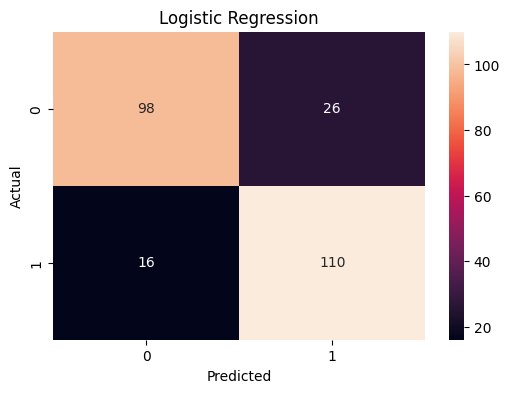

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d"
)

plt.title("Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

2. Naive Bayes

In [8]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", nb_accuracy)

print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.5
              precision    recall  f1-score   support

           0       0.48      0.09      0.15       124
           1       0.50      0.90      0.65       126

    accuracy                           0.50       250
   macro avg       0.49      0.50      0.40       250
weighted avg       0.49      0.50      0.40       250



3. SVM

In [9]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.704
              precision    recall  f1-score   support

           0       0.69      0.73      0.71       124
           1       0.72      0.67      0.70       126

    accuracy                           0.70       250
   macro avg       0.70      0.70      0.70       250
weighted avg       0.70      0.70      0.70       250



Model Comparison

In [10]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "SVM"
    ],
    "Accuracy": [
        lr_accuracy,
        nb_accuracy,
        svm_accuracy
    ]
})

results = results.sort_values(
    by="Accuracy",
    ascending=False
)

print(results)

                 Model  Accuracy
0  Logistic Regression     0.832
2                  SVM     0.704
1          Naive Bayes     0.500


## Best Model Selection

Among the three models tested, Logistic Regression achieved the highest accuracy of 83.2%.

Therefore, Logistic Regression was selected as the final model for predicting whether an employee is likely to seek mental health treatment.

In [12]:
import joblib

joblib.dump(
    lr,
    "../models/mental_health_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


At-Risk Cohort Analysis

In [13]:
age_bins = [18, 25, 35, 45, 70]

age_labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-70"
]

df["Age_Group"] = pd.cut(
    df["Age"],
    bins=age_bins,
    labels=age_labels
)

In [14]:
df[["Age", "Age_Group"]].head(10)

,Age,Age_Group
0,37,36-45
1,44,36-45
2,32,26-35
3,31,26-35
4,31,26-35
5,33,26-35
6,35,26-35
7,39,36-45
8,42,36-45
9,23,18-25


In [16]:
df[["Age", "Age_Group"]].head(1)

,Age,Age_Group
0,37,36-45


Treatment vs Age Group

In [17]:
age_risk = pd.crosstab(
    df["Age_Group"],
    df["treatment"]
)

print(age_risk)

treatment    0    1
Age_Group          
18-25      108  102
26-35      360  341
36-45      124  153
46-70       23   32


Treatment V Gender

In [18]:
gender_risk = pd.crosstab(
    df["Gender"],
    df["treatment"]
)

print(gender_risk)

treatment    0    1
Gender             
Female      18   36
Male       600  587
Other        1    8


Family History vs Treatment

In [19]:
family_risk = pd.crosstab(
    df["family_history"],
    df["treatment"]
)

print(family_risk)

treatment         0    1
family_history          
No              492  270
Yes             127  361


Work Interference vs Treatment

In [20]:
work_risk = pd.crosstab(
    df["work_interfere"],
    df["treatment"]
)

print(work_risk)

treatment         0    1
work_interfere          
Don't know      258    4
Never           182   29
Often            21  119
Rarely           51  122
Sometimes       107  357


1.Family history was the strongest predictor of treatment-seeking behavior.
2.Employees reporting frequent work interference were significantly more likely to seek treatment.
3.Female respondents exhibited higher treatment rates than male respondents.
4.Employees aged 36–45 showed higher treatment-seeking behavior compared to younger groups.
5.Workplace support and awareness remain critical factors influencing employee mental health.

# HR Recommendations
1.Provide targeted mental health support for employees with a family history of mental illness.
2.Monitor employees whose mental health affects work performance, as they represent a high-risk group.
3.Increase awareness of mental health resources and counseling services.
4.Promote early intervention programs to reduce workplace interference caused by mental health issues.
5.Encourage open discussions and reduce stigma around mental health treatment.

# TF-IDF Based Sentiment Analysis

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from textblob import TextBlob

import numpy as np

In [24]:
comments_df = df[df["comments"] != ""].copy()

print(comments_df.shape)

(1250, 28)


In [25]:
comments_df.columns

Index(['Timestamp', 'Age', 'Gender', 'Country', 'state', 'self_employed',
       'family_history', 'treatment', 'work_interfere', 'no_employees',
       'remote_work', 'tech_company', 'benefits', 'care_options',
       'wellness_program', 'seek_help', 'anonymity', 'leave',
       'mental_health_consequence', 'phys_health_consequence', 'coworkers',
       'supervisor', 'mental_health_interview', 'phys_health_interview',
       'mental_vs_physical', 'obs_consequence', 'comments', 'Age_Group'],
      dtype='object')

In [26]:
import nltk
import re

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    text = str(text).lower()

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    tokens = nltk.word_tokenize(text)

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)

comments_df = df[df["comments"] != ""].copy()

comments_df["clean_comments"] = comments_df["comments"].apply(
    preprocess_text
)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=100
)

X_tfidf = tfidf.fit_transform(
    comments_df["clean_comments"]
)

print(X_tfidf.shape)

(1250, 100)


TOP Features

In [28]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:30])

['also' 'answer' 'answered' 'anxiety' 'back' 'benefit' 'bipolar' 'bring'
 'care' 'comfortable' 'company' 'condition' 'could' 'covered' 'coworker'
 'coworkers' 'current' 'day' 'depression' 'didnt' 'discus' 'disorder'
 'doctor' 'doesnt' 'dont' 'employee' 'employer' 'etc' 'even' 'everyone']


TF-IDF DataFrame

In [29]:
tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=tfidf.get_feature_names_out()
)

tfidf_df.head()

,also,answer,answered,anxiety,back,benefit,bipolar,bring,care,comfortable,...,time,treatment,want,week,work,working,workplace,worse,would,year
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
print(X_tfidf.shape)

(1250, 100)


In [31]:
tfidf_df.iloc[0].sort_values(
    ascending=False
).head(10)

nan         1.0
also        0.0
option      0.0
really      0.0
question    0.0
public      0.0
problem     0.0
previous    0.0
policy      0.0
place       0.0
Name: 0, dtype: float64

In [32]:
comments_df[["comments", "clean_comments"]].head(10)

,comments,clean_comments
0,NaN,nan
1,NaN,nan
2,NaN,nan
3,NaN,nan
4,NaN,nan
5,NaN,nan
6,NaN,nan
7,NaN,nan
8,NaN,nan
9,NaN,nan


In [34]:
comments_df["clean_comments"].value_counts().head(20)

clean_comments
nan                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                1089
small family business ymmv                                                                                                                                                                                                                                                                                                                                                                                                                                       

In [36]:
comments_df = df[
    df["comments"].notna()
].copy()

print(comments_df.shape)

(161, 28)


In [37]:
comments_df["clean_comments"] = comments_df["comments"].apply(
    preprocess_text
)

In [38]:
comments_df[["comments", "clean_comments"]].head()

,comments,clean_comments
13,I'm not on my company's health insurance which...,im company health insurance could part reason ...
15,I have chronic low-level neurological issues t...,chronic lowlevel neurological issue mental hea...
16,My company does provide healthcare but not to ...,company provide healthcare im fixedterm contra...
24,Relatively new job. Ask again later,relatively new job ask later
25,Sometimes I think about using drugs for my me...,sometimes think using drug mental health issue...


In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=100
)

X_tfidf = tfidf.fit_transform(
    comments_df["clean_comments"]
)

print(X_tfidf.shape)

(161, 100)


In [40]:
tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=tfidf.get_feature_names_out()
)

tfidf_df.iloc[0].sort_values(
    ascending=False
).head(10)

answered     0.398074
many         0.375912
could        0.375912
insurance    0.357805
question     0.307072
know         0.293191
im           0.284910
company      0.281015
dont         0.245974
health       0.173186
Name: 0, dtype: float64

In [41]:
print(X_tfidf.shape)

(161, 100)


In [42]:
tfidf_df.iloc[0].sort_values(
    ascending=False
).head(10)

answered     0.398074
many         0.375912
could        0.375912
insurance    0.357805
question     0.307072
know         0.293191
im           0.284910
company      0.281015
dont         0.245974
health       0.173186
Name: 0, dtype: float64

In [44]:
from textblob import TextBlob


In [45]:
comments_df["polarity"] = comments_df["comments"].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

In [46]:
def sentiment_label(score):

    if score > 0:
        return "Positive"

    elif score < 0:
        return "Negative"

    else:
        return "Neutral"

comments_df["sentiment"] = comments_df["polarity"].apply(
    sentiment_label
)

In [47]:
comments_df["sentiment"].value_counts()

sentiment
Positive    81
Negative    66
Neutral     14
Name: count, dtype: int64

Train test split 

In [48]:
from sklearn.model_selection import train_test_split

X = X_tfidf
y = comments_df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(128, 100)
(33, 100)


NAIVE BAYES

In [49]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

nb = MultinomialNB()

nb.fit(
    X_train,
    y_train
)

y_pred_nb = nb.predict(
    X_test
)

nb_acc = accuracy_score(
    y_test,
    y_pred_nb
)

print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 0.5454545454545454


In [50]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_nb
    )
)

              precision    recall  f1-score   support

    Negative       0.60      0.23      0.33        13
     Neutral       0.00      0.00      0.00         3
    Positive       0.54      0.88      0.67        17

    accuracy                           0.55        33
   macro avg       0.38      0.37      0.33        33
weighted avg       0.51      0.55      0.47        33



c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

L.R

In [51]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

y_pred_lr = lr.predict(
    X_test
)

from sklearn.metrics import accuracy_score

lr_acc = accuracy_score(
    y_test,
    y_pred_lr
)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.5454545454545454


In [52]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

    Negative       0.60      0.23      0.33        13
     Neutral       0.00      0.00      0.00         3
    Positive       0.54      0.88      0.67        17

    accuracy                           0.55        33
   macro avg       0.38      0.37      0.33        33
weighted avg       0.51      0.55      0.47        33



c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [56]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

print(cm)

[[ 3  0 10]
 [ 0  0  3]
 [ 2  0 15]]


SVM

In [53]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(
    X_train,
    y_train
)

y_pred_svm = svm.predict(
    X_test
)

svm_acc = accuracy_score(
    y_test,
    y_pred_svm
)

print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.5151515151515151


In [54]:
print(
    classification_report(
        y_test,
        y_pred_svm
    )
)

              precision    recall  f1-score   support

    Negative       0.50      0.23      0.32        13
     Neutral       0.00      0.00      0.00         3
    Positive       0.52      0.82      0.64        17

    accuracy                           0.52        33
   macro avg       0.34      0.35      0.32        33
weighted avg       0.46      0.52      0.45        33



c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [55]:
results = {
    "Naive Bayes": nb_acc,
    "Logistic Regression": lr_acc,
    "SVM": svm_acc
}

for model, score in results.items():
    print(
        f"{model}: {score:.4f}"
    )

Naive Bayes: 0.5455
Logistic Regression: 0.5455
SVM: 0.5152
